# Cook Base→Cook v2 – 2-Stage Training + Elastic Augmentation

Improved version of `cook_cook.ipynb` with three changes:

| Change | Reason |
|---|---|
| **2-Stage training** (encoder freeze → full fine-tune) | Prevents overwriting ViT image features on small dataset |
| **Elastic distortion augmentation** (Kornia) | Simulates natural handwriting variation; more effective than photometric augmentation for HTR |
| **Lower LR in Stage 2** (1e-5) | Avoids catastrophic forgetting of Stage 1 decoder weights |

| | Value |
|---|---|
| Starting checkpoint | `microsoft/trocr-base-handwritten` |
| Stage 1 checkpoint | `checkpoints/cook_stage1/` |
| Stage 2 checkpoint | `checkpoints/best_cook_v2/` |
| Val pages | B1_P231, B2_P224, B3_P276, B4_P282, B5_P020, B6_P020 |

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import random
import numpy as np
import torch
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

ROOT             = Path("..")
TRAIN_CROPS_DIR  = ROOT / "data" / "train_set_line_crops"
TEST_CROPS_DIR   = ROOT / "data" / "test_set_line_crops"
MODEL_NAME       = "microsoft/trocr-base-handwritten"
S1_CKPT_DIR      = ROOT / "checkpoints" / "cook_stage1"
S2_CKPT_DIR      = ROOT / "checkpoints" / "best_cook_v2"

# ── Hyperparameters ────────────────────────────────────────────────────────
MAX_TARGET_LENGTH = 128
TRAIN_BATCH_SIZE  = 8
EVAL_BATCH_SIZE   = 8
NUM_BEAMS         = 4
WARMUP_RATIO      = 0.1

# Stage 1 — encoder frozen, decoder only
LR_S1         = 1e-4
EPOCHS_S1     = 20
PATIENCE_S1   = 5

# Stage 2 — full model
LR_S2         = 1e-5
EPOCHS_S2     = 20
PATIENCE_S2   = 5

gc.collect()
torch.cuda.empty_cache()

print(f"Random seed : {SEED}")
for p in [TRAIN_CROPS_DIR, TEST_CROPS_DIR]:
    print(f"  {'✓' if p.exists() else '✗'} {p}")

Random seed : 42
  ✓ ../data/train_set_line_crops
  ✓ ../data/test_set_line_crops


## Step 1 – Load Data

In [2]:
import pandas as pd

def build_dataframe(crops_dir: Path) -> pd.DataFrame:
    records = []
    for page_dir in sorted(crops_dir.iterdir()):
        if not page_dir.is_dir():
            continue
        for img_path in sorted(page_dir.glob("*.jpg")):
            txt_path = img_path.with_suffix(".txt")
            if txt_path.exists():
                transcription = txt_path.read_text(encoding="utf-8").strip()
                records.append({
                    "image_path":    str(img_path),
                    "page":          page_dir.name,
                    "transcription": transcription,
                })
    return pd.DataFrame(records)


df_all_train = build_dataframe(TRAIN_CROPS_DIR)
df_test      = build_dataframe(TEST_CROPS_DIR)

VAL_PAGES = {"B1_P231", "B2_P224", "B3_P276", "B4_P282", "B5_P020", "B6_P020"}

df_train = df_all_train[~df_all_train["page"].isin(VAL_PAGES)].reset_index(drop=True)
df_val   = df_all_train[ df_all_train["page"].isin(VAL_PAGES)].reset_index(drop=True)

print(f"Train lines : {len(df_train):>5}")
print(f"Val lines   : {len(df_val):>5}")
print(f"Test lines  : {len(df_test):>5}")

Train lines :   726
Val lines   :   194
Test lines  :   189


## Step 2 – Augmentation Pipeline

Applied **only during training**. Val and test always receive the raw image.

Kornia's `RandomElasticTransform` simulates natural handwriting variation by warping the image
with a smooth random displacement field — effective for HTR without distorting character shapes
beyond recognition.

Applied on the already-processed `pixel_values` tensor (3 × 384 × 384) after the TrOCR
processor resizes the image, so no extra PIL roundtrip is needed.

In [3]:
from PIL import Image as PILImage
import kornia.augmentation as K

# kernel_size: controls smoothness of the displacement field (must be odd)
# sigma:       Gaussian std — larger = smoother, less localised warp
# alpha:       displacement magnitude range — small values keep characters readable
elastic_aug = K.RandomElasticTransform(
    kernel_size=(63, 63),
    sigma=(32.0, 32.0),
    alpha=(1.0, 2.0),
    p=0.5,
)

print("Kornia RandomElasticTransform defined.")

Kornia RandomElasticTransform defined.


## Step 3 – Dataset & DataLoaders

In [4]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
print(f"Processor loaded from: {MODEL_NAME}")

Processor loaded from: microsoft/trocr-base-handwritten


In [5]:
from torch.utils.data import Dataset, DataLoader


class CookDataset(Dataset):
    def __init__(self, df, processor, augment=False, max_target_length=MAX_TARGET_LENGTH):
        self.df                = df
        self.processor         = processor
        self.augment           = augment
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = PILImage.open(row["image_path"]).convert("RGB")

        # processor: PIL → normalised float tensor (3, 384, 384)
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)

        if self.augment:
            # kornia expects (B, C, H, W); add/remove batch dim
            pixel_values = elastic_aug(pixel_values.unsqueeze(0)).squeeze(0)

        labels = self.processor.tokenizer(
            row["transcription"],
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}


train_loader = DataLoader(
    CookDataset(df_train, processor, augment=True),
    batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=0,
)
val_loader = DataLoader(
    CookDataset(df_val, processor, augment=False),
    batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0,
)
test_loader = DataLoader(
    CookDataset(df_test, processor, augment=False),
    batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print("DataLoaders OK.")

Train batches : 91
Val batches   : 25
DataLoaders OK.


## Step 4 – Stage 1: Encoder Frozen, Decoder Only

The ViT encoder is frozen — its pre-trained image features are preserved.  
Only the decoder (RoBERTa) trains, learning Cook vocabulary at a high LR (1e-4).

> **Note:** Gradient checkpointing is intentionally **disabled** in Stage 1.  
> With a frozen encoder, `torch.utils.checkpoint` cannot propagate gradients and training diverges.  
> It is re-enabled in Stage 2 after the encoder is unfrozen.

In [6]:
from transformers import VisionEncoderDecoderModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated(device) / 1024**3
    total_mem = torch.cuda.get_device_properties(device).total_memory / 1024**3
    print(f"Device : {device}  —  {total_mem:.1f} GB total  |  {allocated:.2f} GB allocated")
else:
    print(f"Device : {device}")

model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.eos_token_id           = processor.tokenizer.sep_token_id
model.config.use_cache              = False
# gradient_checkpointing NOT enabled here — incompatible with frozen encoder
model.to(device)

# Freeze encoder
for param in model.encoder.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable : {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print("Encoder: ❄️ Frozen   |   Decoder: 🔥 Trainable")

Device : cuda  —  11.6 GB total  |  0.00 GB allocated


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable : 247,268,352 / 333,921,792  (74.0%)
Encoder: ❄️ Frozen   |   Decoder: 🔥 Trainable


In [7]:
from torch.optim import AdamW
from transformers import get_scheduler

total_steps_s1  = EPOCHS_S1 * len(train_loader)
warmup_steps_s1 = int(total_steps_s1 * WARMUP_RATIO)

optimizer_s1 = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_S1,
)
scheduler_s1 = get_scheduler(
    name="linear", optimizer=optimizer_s1,
    num_warmup_steps=warmup_steps_s1, num_training_steps=total_steps_s1,
)
print(f"Stage 1 — Steps: {total_steps_s1}  |  Warmup: {warmup_steps_s1}  |  LR: {LR_S1}")

Stage 1 — Steps: 1820  |  Warmup: 182  |  LR: 0.0001


In [8]:
import evaluate

cer_metric = evaluate.load("cer")


def compute_cer(model, dataloader, processor, device):
    model.eval()
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in dataloader:
            pixel_values  = batch["pixel_values"].to(device)
            labels        = batch["labels"].clone()
            generated_ids = model.generate(
                pixel_values, max_new_tokens=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS
            )
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs  = processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    return cer_metric.compute(predictions=all_preds, references=all_refs)

In [9]:
from tqdm.notebook import tqdm

S1_CKPT_DIR.mkdir(parents=True, exist_ok=True)

best_cer_s1      = float("inf")
patience_counter = 0
history_s1       = []
scaler           = torch.amp.GradScaler("cuda")

torch.cuda.empty_cache()

for epoch in range(1, EPOCHS_S1 + 1):

    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"S1 Epoch {epoch:02d}/{EPOCHS_S1}", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)
        optimizer_s1.zero_grad()
        with torch.amp.autocast("cuda"):
            outputs = model(pixel_values=pixel_values, labels=labels)
        scaler.scale(outputs.loss).backward()
        scaler.step(optimizer_s1)
        scaler.update()
        scheduler_s1.step()
        total_loss += outputs.loss.item()

    avg_loss = total_loss / len(train_loader)
    val_cer  = compute_cer(model, val_loader, processor, device)

    history_s1.append({"epoch": epoch, "train_loss": avg_loss, "val_cer": val_cer})
    print(f"[S1] Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Val CER: {val_cer:.4f}", end="")

    if val_cer < best_cer_s1:
        best_cer_s1      = val_cer
        patience_counter = 0
        model.save_pretrained(S1_CKPT_DIR)
        processor.save_pretrained(S1_CKPT_DIR)
        print(f"  ✓ Stage 1 best saved")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement ({patience_counter}/{PATIENCE_S1})")
        if patience_counter >= PATIENCE_S1:
            print(f"\nEarly stopping — Stage 1 best Val CER: {best_cer_s1:.4f}")
            break

S1 Epoch 01/20:   0%|          | 0/91 [00:00<?, ?it/s]

[S1] Epoch 01 | Loss: 3.6055 | Val CER: 0.2167

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Stage 1 best saved


S1 Epoch 02/20:   0%|          | 0/91 [00:00<?, ?it/s]

...

[S1] Epoch 04 | Loss: 2.5341 | Val CER: 1.3552  ✗ No improvement (3/5)


S1 Epoch 05/20:   0%|          | 0/91 [00:00<?, ?it/s]

[S1] Epoch 05 | Loss: 1.7637 | Val CER: 0.6209  ✗ No improvement (4/5)


S1 Epoch 06/20:   0%|          | 0/91 [00:00<?, ?it/s]

[S1] Epoch 06 | Loss: 1.0719 | Val CER: 0.3977  ✗ No improvement (5/5)

Early stopping — Stage 1 best Val CER: 0.2167


## Step 5 – Stage 2: Full Model Fine-Tuning

Load best Stage 1 checkpoint, unfreeze encoder, fine-tune everything at low LR (1e-5).  
Gradient checkpointing re-enabled now that all parameters are trainable.

In [10]:
import gc

# Free Stage 1 model before loading Stage 2
del model
gc.collect()
torch.cuda.empty_cache()

model_s2 = VisionEncoderDecoderModel.from_pretrained(S1_CKPT_DIR)
model_s2.config.use_cache = False
model_s2.gradient_checkpointing_enable()
model_s2.to(device)

# Unfreeze everything
for param in model_s2.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model_s2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_s2.parameters())
print(f"Stage 1 checkpoint   : {S1_CKPT_DIR}")
print(f"Trainable parameters : {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print("Encoder: 🔥 Trainable   |   Decoder: 🔥 Trainable")

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Stage 1 checkpoint   : ../checkpoints/cook_stage1
Trainable parameters : 333,921,792 / 333,921,792  (100.0%)
Encoder: 🔥 Trainable   |   Decoder: 🔥 Trainable


In [11]:
total_steps_s2  = EPOCHS_S2 * len(train_loader)
warmup_steps_s2 = int(total_steps_s2 * WARMUP_RATIO)

optimizer_s2 = AdamW(model_s2.parameters(), lr=LR_S2)
scheduler_s2 = get_scheduler(
    name="linear", optimizer=optimizer_s2,
    num_warmup_steps=warmup_steps_s2, num_training_steps=total_steps_s2,
)
print(f"Stage 2 — Steps: {total_steps_s2}  |  Warmup: {warmup_steps_s2}  |  LR: {LR_S2}")

Stage 2 — Steps: 1820  |  Warmup: 182  |  LR: 1e-05


In [12]:
S2_CKPT_DIR.mkdir(parents=True, exist_ok=True)

best_cer_s2      = float("inf")
patience_counter = 0
history_s2       = []
scaler_s2        = torch.amp.GradScaler("cuda")

torch.cuda.empty_cache()

for epoch in range(1, EPOCHS_S2 + 1):

    model_s2.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"S2 Epoch {epoch:02d}/{EPOCHS_S2}", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)
        optimizer_s2.zero_grad()
        with torch.amp.autocast("cuda"):
            outputs = model_s2(pixel_values=pixel_values, labels=labels)
        scaler_s2.scale(outputs.loss).backward()
        scaler_s2.step(optimizer_s2)
        scaler_s2.update()
        scheduler_s2.step()
        total_loss += outputs.loss.item()

    avg_loss = total_loss / len(train_loader)
    val_cer  = compute_cer(model_s2, val_loader, processor, device)

    history_s2.append({"epoch": epoch, "train_loss": avg_loss, "val_cer": val_cer})
    print(f"[S2] Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Val CER: {val_cer:.4f}", end="")

    if val_cer < best_cer_s2:
        best_cer_s2      = val_cer
        patience_counter = 0
        model_s2.save_pretrained(S2_CKPT_DIR)
        processor.save_pretrained(S2_CKPT_DIR)
        print(f"  ✓ Stage 2 best saved")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement ({patience_counter}/{PATIENCE_S2})")
        if patience_counter >= PATIENCE_S2:
            print(f"\nEarly stopping — Stage 2 best Val CER: {best_cer_s2:.4f}")
            break

S2 Epoch 01/20:   0%|          | 0/91 [00:00<?, ?it/s]

[S2] Epoch 01 | Loss: 1.5770 | Val CER: 0.1200

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Stage 2 best saved


S2 Epoch 02/20:   0%|          | 0/91 [00:00<?, ?it/s]

...

[S2] Epoch 14 | Loss: 0.1232 | Val CER: 0.0825  ✗ No improvement (3/5)


S2 Epoch 15/20:   0%|          | 0/91 [00:00<?, ?it/s]

[S2] Epoch 15 | Loss: 0.0786 | Val CER: 0.0802  ✗ No improvement (4/5)


S2 Epoch 16/20:   0%|          | 0/91 [00:00<?, ?it/s]

[S2] Epoch 16 | Loss: 0.0641 | Val CER: 0.0778  ✗ No improvement (5/5)

Early stopping — Stage 2 best Val CER: 0.0776


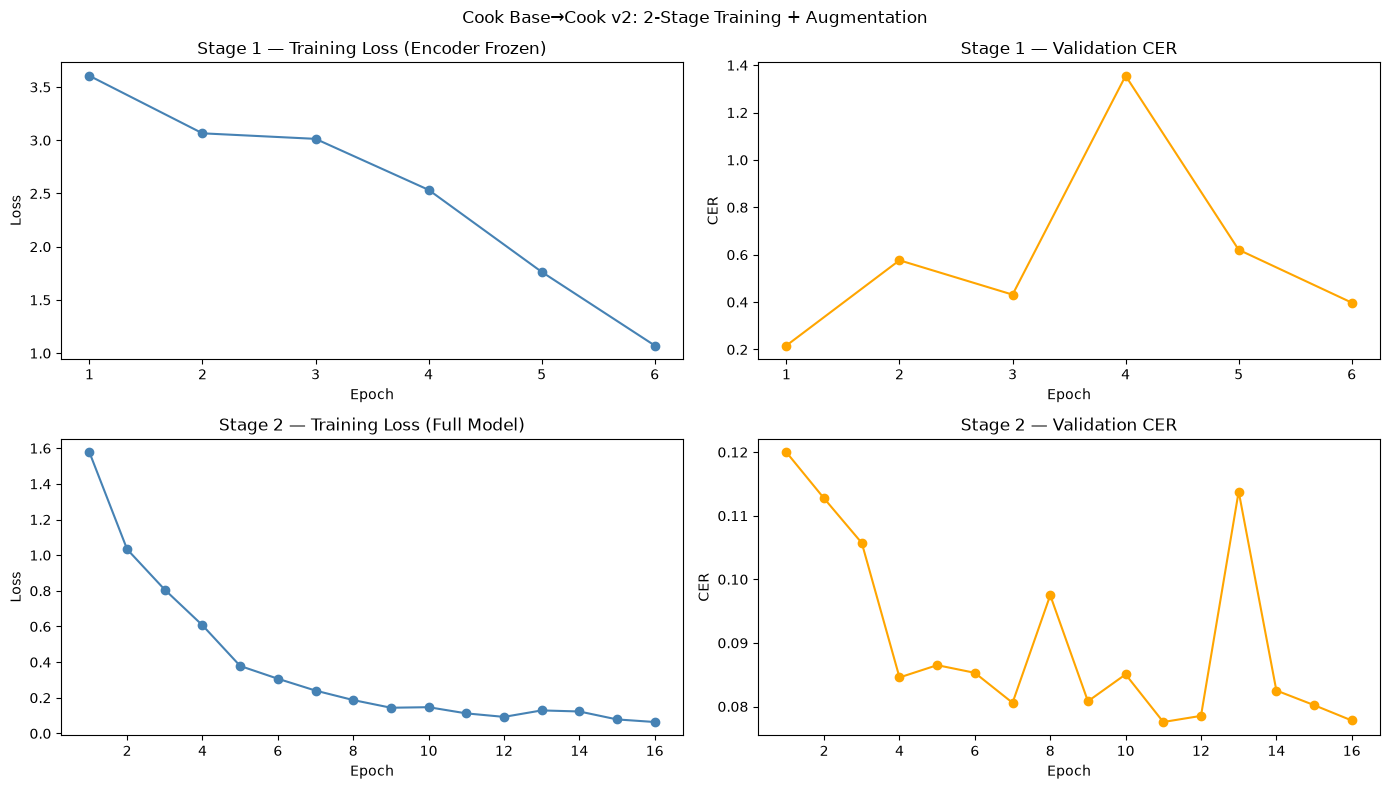

Stage 1 best Val CER : 0.2167
Stage 2 best Val CER : 0.0776


In [13]:
import matplotlib.pyplot as plt

history_s1_df = pd.DataFrame(history_s1)
history_s2_df = pd.DataFrame(history_s2)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0][0].plot(history_s1_df["epoch"], history_s1_df["train_loss"], marker="o", color="steelblue")
axes[0][0].set_title("Stage 1 — Training Loss (Encoder Frozen)")
axes[0][0].set_xlabel("Epoch"); axes[0][0].set_ylabel("Loss")

axes[0][1].plot(history_s1_df["epoch"], history_s1_df["val_cer"], marker="o", color="orange")
axes[0][1].set_title("Stage 1 — Validation CER")
axes[0][1].set_xlabel("Epoch"); axes[0][1].set_ylabel("CER")

axes[1][0].plot(history_s2_df["epoch"], history_s2_df["train_loss"], marker="o", color="steelblue")
axes[1][0].set_title("Stage 2 — Training Loss (Full Model)")
axes[1][0].set_xlabel("Epoch"); axes[1][0].set_ylabel("Loss")

axes[1][1].plot(history_s2_df["epoch"], history_s2_df["val_cer"], marker="o", color="orange")
axes[1][1].set_title("Stage 2 — Validation CER")
axes[1][1].set_xlabel("Epoch"); axes[1][1].set_ylabel("CER")

plt.suptitle("Cook Base→Cook v2: 2-Stage Training + Augmentation", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Stage 1 best Val CER : {history_s1_df['val_cer'].min():.4f}")
print(f"Stage 2 best Val CER : {history_s2_df['val_cer'].min():.4f}")

## Step 6 – Evaluation

Load best Stage 2 checkpoint → CER & WER on all splits.  
Self-contained: can be run after a kernel restart without retraining.

In [2]:
import torch
import evaluate
import pandas as pd
from pathlib import Path
from PIL import Image as PILImage
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from transformers import VisionEncoderDecoderModel, TrOCRProcessor

ROOT        = Path("..")
S2_CKPT_DIR = ROOT / "checkpoints" / "best_cook_v2"
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_model     = VisionEncoderDecoderModel.from_pretrained(S2_CKPT_DIR).to(device)
best_processor = TrOCRProcessor.from_pretrained(S2_CKPT_DIR)
best_model.eval()

print(f"Device     : {device}")
print(f"Checkpoint : {S2_CKPT_DIR}")

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Device     : cuda
Checkpoint : ../checkpoints/best_cook_v2


In [3]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

MAX_TARGET_LENGTH = 128
EVAL_BATCH_SIZE   = 8
NUM_BEAMS         = 4


class _CookDataset(Dataset):
    def __init__(self, df, processor):
        self.df, self.processor = df, processor

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = PILImage.open(row["image_path"]).convert("RGB")
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"], padding="max_length",
            max_length=MAX_TARGET_LENGTH, truncation=True, return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}


def evaluate_split(df_split, label):
    loader = DataLoader(
        _CookDataset(df_split, best_processor),
        batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0,
    )
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Eval {label}", leave=False):
            pixel_values  = batch["pixel_values"].to(device)
            labels        = batch["labels"].clone()
            generated_ids = best_model.generate(
                pixel_values, max_new_tokens=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS
            )
            preds = best_processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = best_processor.tokenizer.pad_token_id
            refs  = best_processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    cer = cer_metric.compute(predictions=all_preds, references=all_refs)
    wer = wer_metric.compute(predictions=all_preds, references=all_refs)
    return cer, wer, all_preds, all_refs


# Rebuild DataFrames (self-contained after kernel restart)
TRAIN_CROPS_DIR = ROOT / "data" / "train_set_line_crops"
TEST_CROPS_DIR  = ROOT / "data" / "test_set_line_crops"
VAL_PAGES       = {"B1_P231", "B2_P224", "B3_P276", "B4_P282", "B5_P020", "B6_P020"}

def _build_df(crops_dir):
    records = []
    for page_dir in sorted(Path(crops_dir).iterdir()):
        if not page_dir.is_dir(): continue
        for img_path in sorted(page_dir.glob("*.jpg")):
            txt_path = img_path.with_suffix(".txt")
            if txt_path.exists():
                records.append({"image_path": str(img_path), "page": page_dir.name,
                                 "transcription": txt_path.read_text(encoding="utf-8").strip()})
    return pd.DataFrame(records)

df_all  = _build_df(TRAIN_CROPS_DIR)
df_test = _build_df(TEST_CROPS_DIR)
df_train_eval = df_all[~df_all["page"].isin(VAL_PAGES)].reset_index(drop=True)
df_val_eval   = df_all[ df_all["page"].isin(VAL_PAGES)].reset_index(drop=True)

train_cer, train_wer, train_preds, train_refs = evaluate_split(df_train_eval, "Train")
val_cer,   val_wer,   val_preds,   val_refs   = evaluate_split(df_val_eval,   "Val")
test_cer,  test_wer,  test_preds,  test_refs  = evaluate_split(df_test,       "Test")

results = pd.DataFrame([
    {"Split": "Train", "Lines": len(train_refs), "CER": round(train_cer, 4), "WER": round(train_wer, 4)},
    {"Split": "Val",   "Lines": len(val_refs),   "CER": round(val_cer,   4), "WER": round(val_wer,   4)},
    {"Split": "Test",  "Lines": len(test_refs),  "CER": round(test_cer,  4), "WER": round(test_wer,  4)},
])
print(results.to_string(index=False))

Eval Train:   0%|          | 0/91 [00:00<?, ?it/s]

Eval Val:   0%|          | 0/25 [00:00<?, ?it/s]

Eval Test:   0%|          | 0/24 [00:00<?, ?it/s]

Split  Lines    CER    WER
Train    726 0.0040 0.0080
  Val    194 0.0776 0.2000
 Test    189 0.1153 0.2402


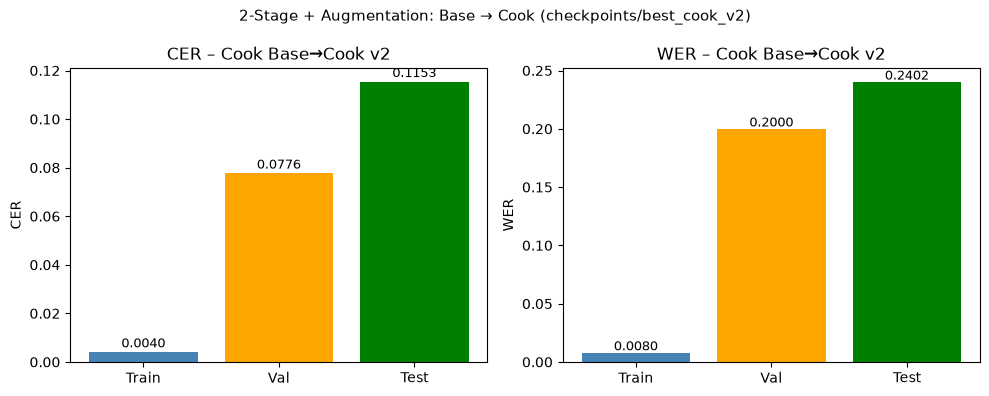

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x      = range(len(results))
colors = ["steelblue", "orange", "green"]

for ax, metric in zip(axes, ["CER", "WER"]):
    ax.bar(x, results[metric], color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(results["Split"])
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} – Cook Base→Cook v2")
    for i, v in enumerate(results[metric]):
        ax.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("2-Stage + Augmentation: Base → Cook (checkpoints/best_cook_v2)", fontsize=11)
plt.tight_layout()
plt.show()

## Step 7 – Qualitative Examples (Test Set)

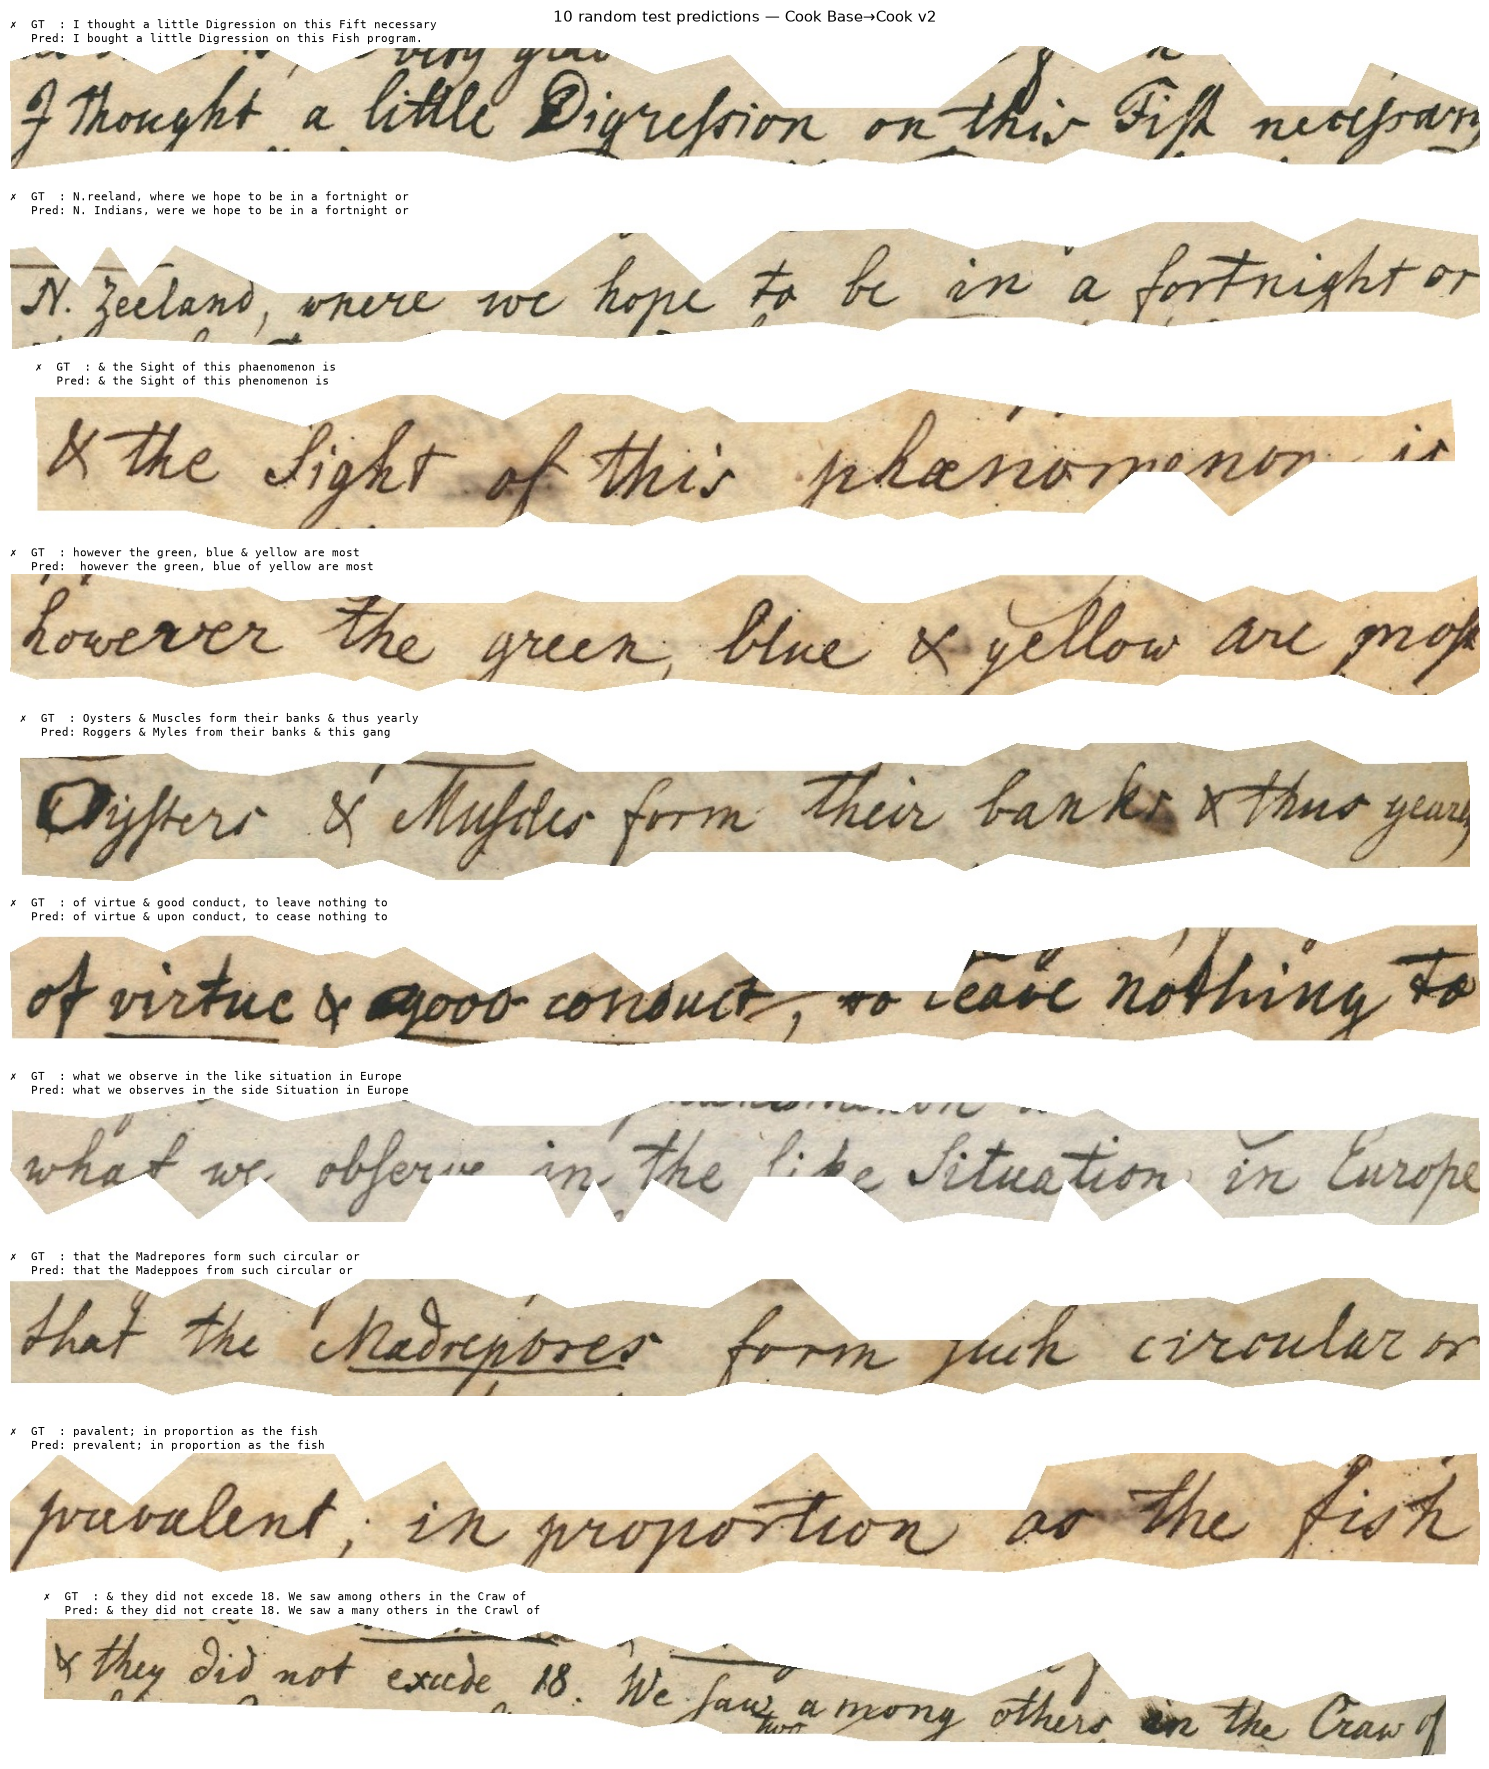

In [5]:
sample_idx = df_test.sample(10, random_state=42).index.tolist()

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, idx in zip(axes, sample_idx):
    row   = df_test.iloc[idx]
    img   = PILImage.open(row["image_path"]).convert("RGB")
    pred  = test_preds[idx]
    ref   = test_refs[idx]
    match = "✓" if pred.strip() == ref.strip() else "✗"
    ax.imshow(img)
    ax.set_title(
        f"{match}  GT  : {ref}\n   Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")
plt.suptitle("10 random test predictions — Cook Base→Cook v2", fontsize=11)
plt.tight_layout()
plt.show()

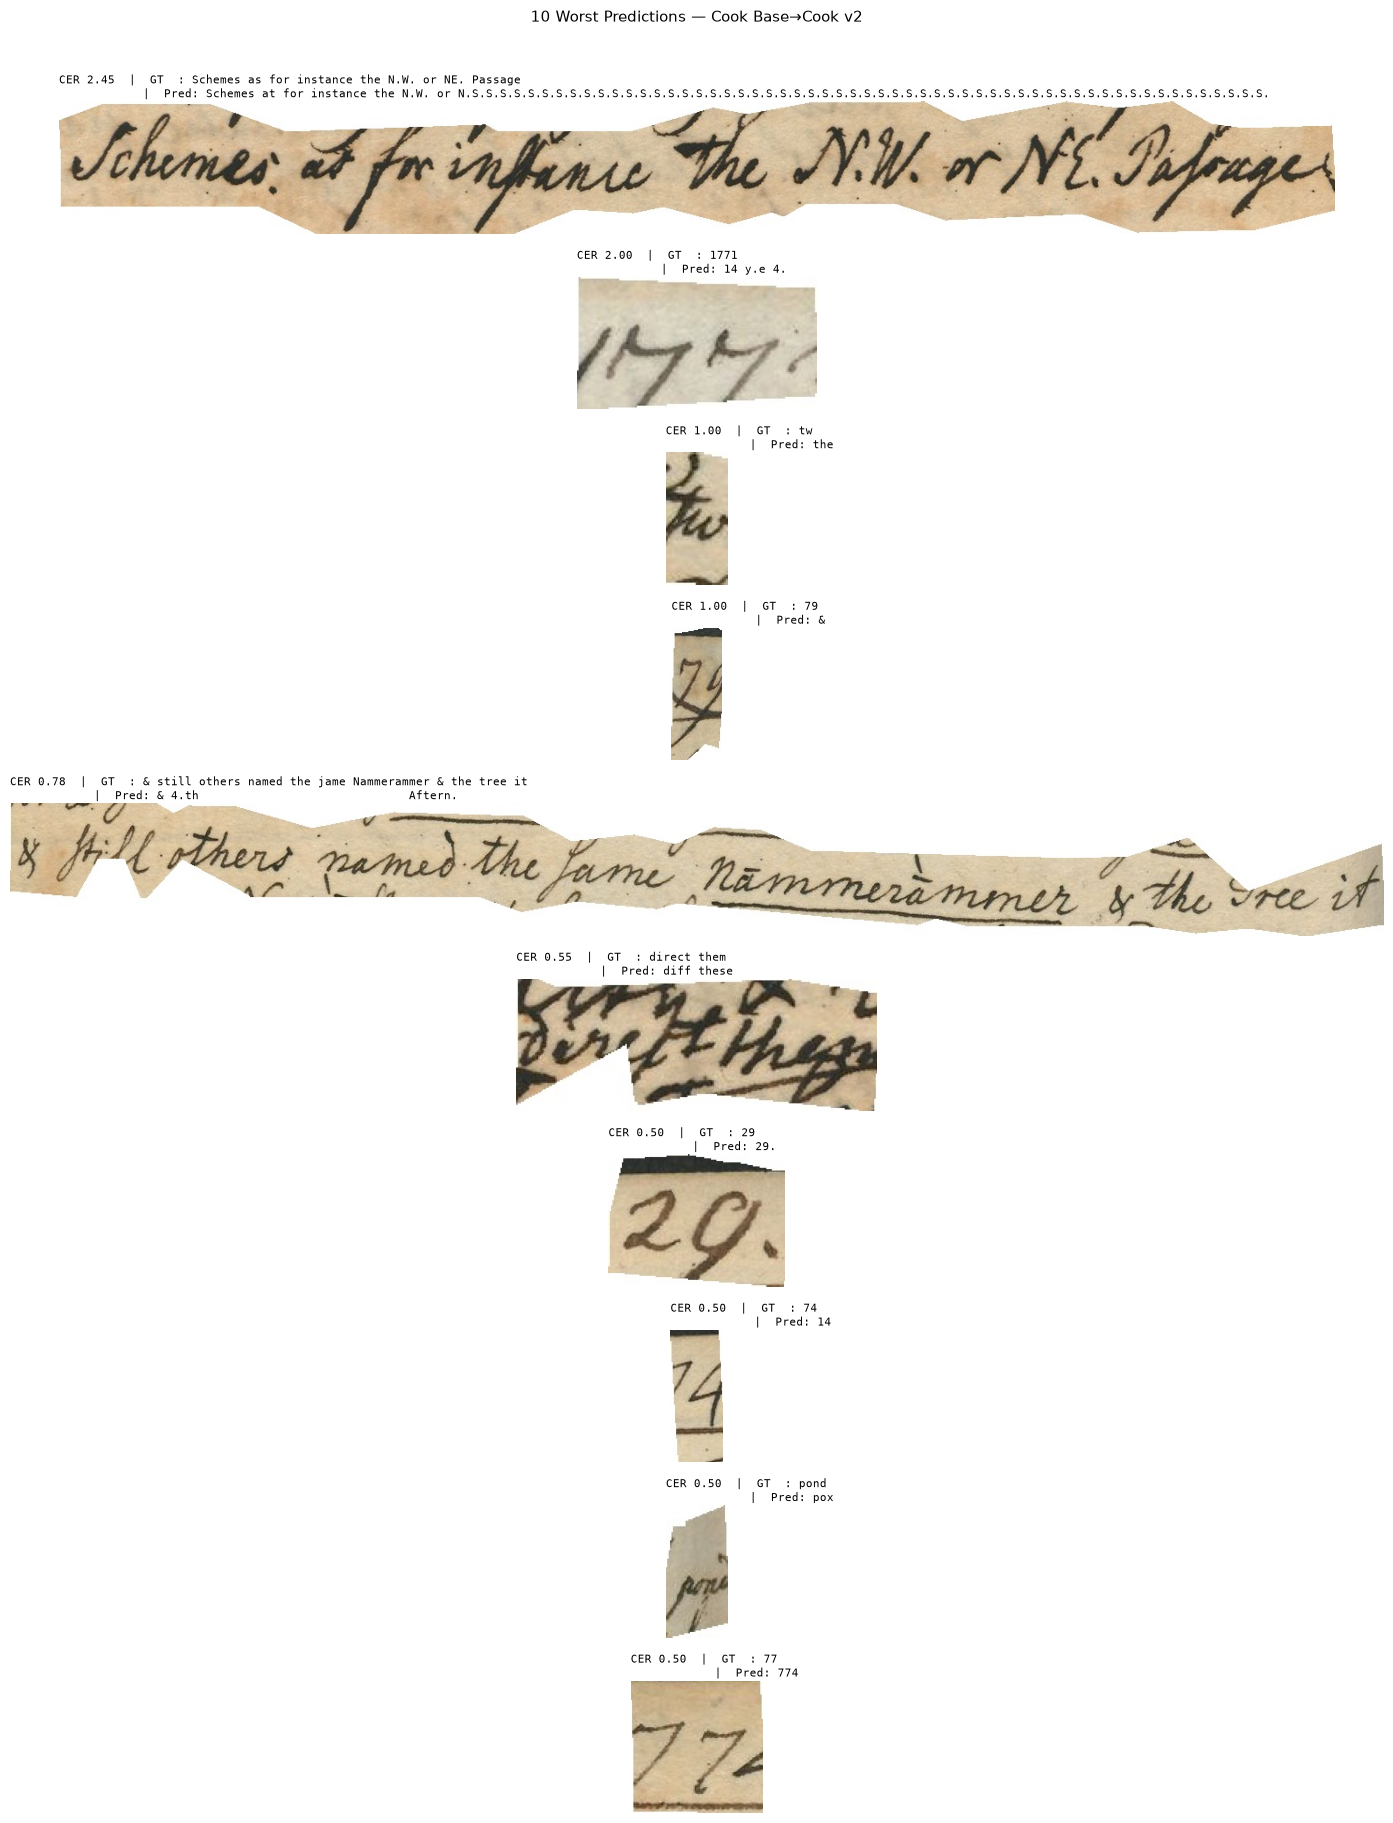

In [6]:
from jiwer import cer as line_cer

errors = sorted(
    [(line_cer(ref, pred), idx, ref, pred)
     for idx, (pred, ref) in enumerate(zip(test_preds, test_refs)) if ref.strip()],
    reverse=True,
)

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, (c, idx, ref, pred) in zip(axes, errors[:10]):
    row = df_test.iloc[idx]
    img = PILImage.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"CER {c:.2f}  |  GT  : {ref}\n"
        f"            |  Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("10 Worst Predictions — Cook Base→Cook v2", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()